# 🎮 Game Data Analytics – Intern Assignment

**Mục tiêu:** Phân tích dữ liệu game để xác định các level có vấn đề, đo tỉ lệ bỏ chơi và độ khó bất thường.

**Dataset:** `Intern_Test_Data_-_Data.csv` – log sự kiện người chơi qua các cấp độ.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#  Load dữ liệu
df = pd.read_csv(r"C:\Users\THINHKPAD\Downloads\ Data.csv")

# Sửa kiểu dữ liệu is_success
df['is_success'] = df['is_success'].astype(str).map({'True': True, 'False': False, 'nan': None})

# Tách event start/end
ends   = df[df['event_name'] == 'level_end'].copy()
starts = df[df['event_name'] == 'level_start'].copy()

print('Data loaded:', df.shape)

Data loaded: (116644, 14)


---
## **1️. Phân tích Khám phá Dữ liệu (EDA)**

### 1.1 Thống kê tổng quan

In [2]:
summary = {
    'Tổng số records': f"{len(df):,}",
    'level_start events': f"{len(starts):,}",
    'level_end events': f"{len(ends):,}",
    'Unique users': f"{df['user_id'].nunique():,}",
    'Unique levels': f"{df['level'].nunique():,}",
    'Level range': f"{int(df['level'].min())} – {int(df['level'].max())}",
    'Win rate tổng thể': f"{(ends['is_success']==True).sum()/len(ends)*100:.1f}%",
    'Thời gian chơi trung bình (s)': f"{ends['time_played'].mean():.1f}",
    'Max time_played (giờ)': f"{ends['time_played'].max()/3600:.1f}",
}
pd.DataFrame.from_dict(summary, orient='index', columns=['Giá trị'])

,Giá trị
Tổng số records,"116,644"
level_start events,"63,927"
level_end events,"52,717"
Unique users,994
Unique levels,"6,324"
Level range,1 – 9046
Win rate tổng thể,62.5%
Thời gian chơi trung bình (s),224.8
Max time_played (giờ),23.1


### 1.2 Kiểm tra dữ liệu bất thường (Data Quality)

In [3]:
# Kiểm tra giá trị NULL
null_df = df.isnull().sum().rename('Null count').to_frame()
null_df['Null %'] = (null_df['Null count'] / len(df) * 100).round(2)
null_df = null_df[null_df['Null count'] > 0]
print('=== Giá trị NULL ===')
print(null_df.to_string())
print()

=== Giá trị NULL ===
                   Null count  Null %
user_id                   666    0.57
app_version               607    0.52
time_played             64549   55.34
level                     618    0.53
is_success              64541   55.33
game_mode                 593    0.51
mobile_brand_name         588    0.50



In [4]:
# Kiểm tra dữ liệu trùng
n_dup = df.duplicated(subset=['user_id','event_timestamp','batch_event_index']).sum()
print(f'Exact duplicate events: {n_dup}')

# Kiểm tra level_start chưa có level_end
unmatched = len(starts) - len(ends)
print(f'level_start không có level_end tương ứng: {unmatched} ({unmatched/len(starts)*100:.1f}%)')

# Kiểm tra time_played bất thường
print(f'time_played > 3600s (>1hr): {(ends["time_played"] > 3600).sum()} records')
print(f'time_played max: {ends["time_played"].max():.0f}s = {ends["time_played"].max()/3600:.1f} giờ')

# Phân tích số lần retry theo level
attempt_df = ends.dropna(subset=['user_id']).groupby(['user_id','level']).size().reset_index(name='n')
print(f'User-level pairs với 50+ attempts: {(attempt_df["n"]>=50).sum()}')

Exact duplicate events: 4396
level_start không có level_end tương ứng: 11210 (17.5%)
time_played > 3600s (>1hr): 68 records
time_played max: 83283s = 23.1 giờ
User-level pairs với 50+ attempts: 28


**💡 Nhận xét về data quality:**
- **Missing user_id (666 rows):** Có thể đến từ anonymous session hoặc lỗi tracking trong quá trình ghi nhận dữ liệu. Các record này không phù hợp cho phân tích hành vi theo user → loại bỏ ở các bước phân tích retention/drop-off.
- **Missing level (618 rows):** Một số event không có thông tin level nên không thể sử dụng trong các phân tích progression hoặc difficulty theo level.
- **level_start > level_end (11,210 cases = 17.5%):** Số lượt bắt đầu level nhiều hơn số lượt hoàn thành cho thấy một phần người chơi đã thoát game giữa chừng hoặc chưa kết thúc session. Đây có thể là tín hiệu của churn hoặc trải nghiệm chơi chưa tối ưu.
- **Exact duplicate events (4,396):** Có thể do retry từ client hoặc batch processing. Cần kiểm tra trước khi count.
- **time_played max = 23.1 giờ:** Giá trị này là outlier rõ ràng, nhiều khả năng do người chơi để game chạy background hoặc lỗi tracking thời gian. Nên cân nhắc loại bỏ hoặc giới hạn ngưỡng khi phân tích gameplay time.
- **28 user-level pairs với 50+ attempts:** Một số level cực kỳ khó hoặc user bị kẹt (ví dụ level 225 có max 905 attempts!).

### 1.3 Phân phối dữ liệu

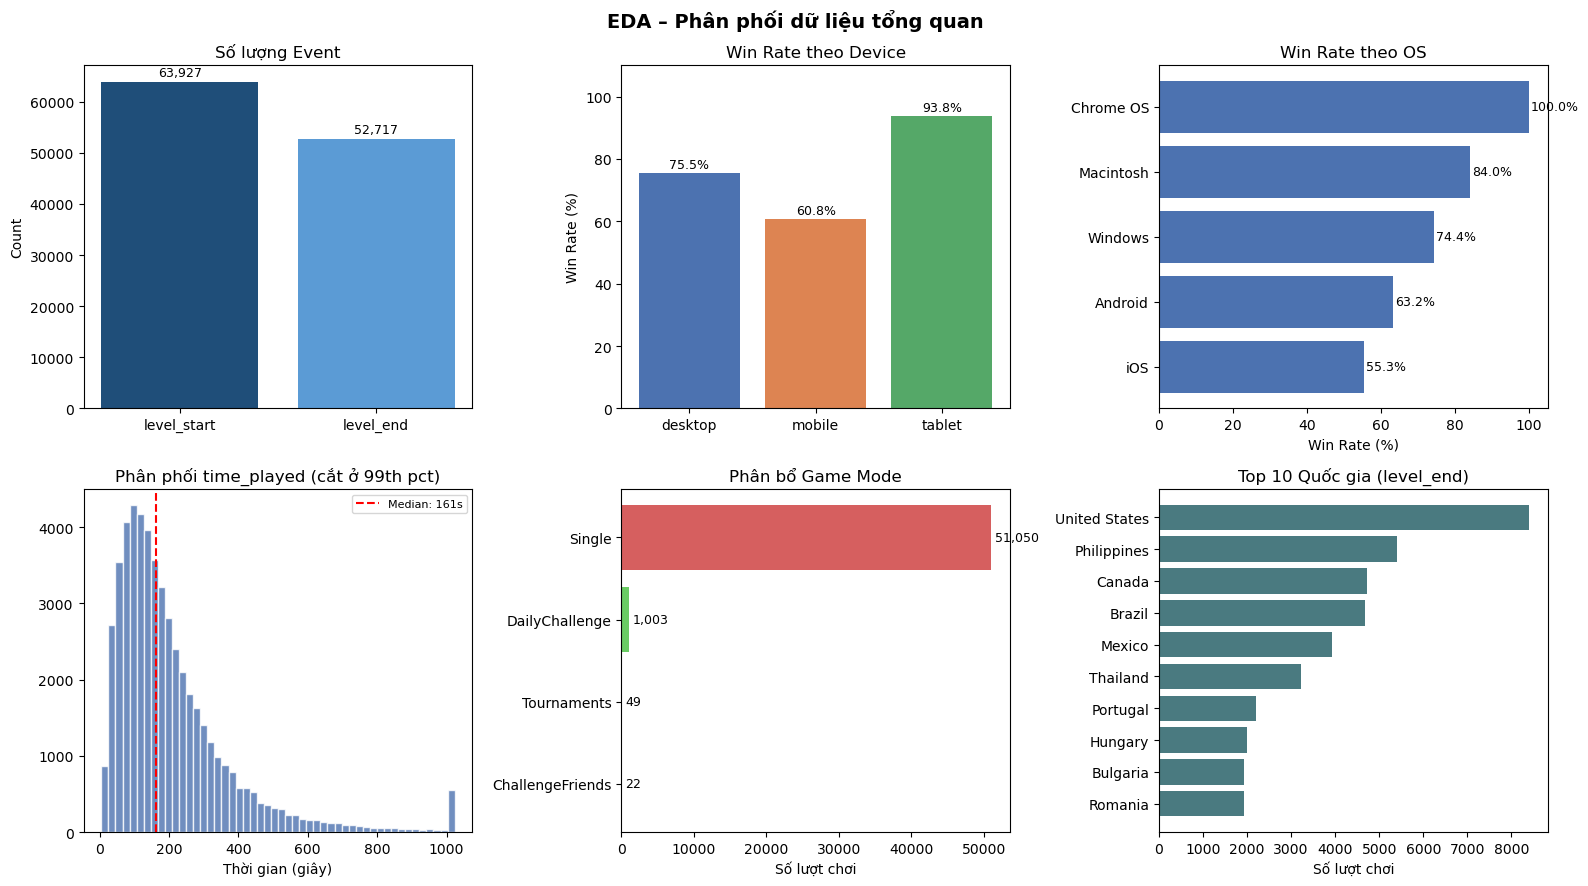

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('EDA – Phân phối dữ liệu tổng quan', fontsize=14, fontweight='bold')

# 1) Event distribution 
ax = axes[0,0]
event_counts = df['event_name'].value_counts()
bars = ax.bar(event_counts.index, event_counts.values, color=['#1F4E79', '#5B9BD5'])
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+500, f'{bar.get_height():,}',
            ha='center', va='bottom', fontsize=9)
ax.set_title('Số lượng Event')
ax.set_ylabel('Count')

# 2) Win rate by device
ax = axes[0,1]
wr_device = ends.groupby('device_category')['is_success'].apply(
    lambda x: (x==True).sum()/len(x)*100).round(1)
colors = ['#4C72B0','#DD8452','#55A868']
bars = ax.bar(wr_device.index, wr_device.values, color=colors)
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f'{bar.get_height():.1f}%',
            ha='center', va='bottom', fontsize=9)
ax.set_title('Win Rate theo Device')
ax.set_ylabel('Win Rate (%)')
ax.set_ylim(0, 110)

# 3) Win rate by OS
ax = axes[0,2]
wr_os = ends.groupby('operating_system')['is_success'].apply(
    lambda x: (x==True).sum()/len(x)*100).round(1).sort_values(ascending=True)
ax.barh(wr_os.index, wr_os.values, color='#4C72B0')
for i, v in enumerate(wr_os.values):
    ax.text(v+0.5, i, f'{v:.1f}%', va='center', fontsize=9)
ax.set_title('Win Rate theo OS')
ax.set_xlabel('Win Rate (%)')

# 4) time_played distribution (cap at 99th percentile)
ax = axes[1,0]
cap = ends['time_played'].quantile(0.99)
tp_clipped = ends['time_played'].clip(upper=cap)
ax.hist(tp_clipped.dropna(), bins=50, color='#4C72B0', edgecolor='white', alpha=0.8)
ax.axvline(ends['time_played'].median(), color='red', linestyle='--', label=f'Median: {ends["time_played"].median():.0f}s')
ax.set_title('Phân phối time_played (cắt ở 99th pct)')
ax.set_xlabel('Thời gian (giây)')
ax.legend(fontsize=8)

# 5) Game mode breakdown (Chuyển sang Bar chart)
ax = axes[1,1]
gm = ends['game_mode'].value_counts().sort_values(ascending=True)

bars = ax.barh(gm.index, gm.values, color=sns.color_palette('muted', len(gm)))
for bar in bars:
    width = bar.get_width()
    ax.text(width + (gm.values.max()*0.01), bar.get_y() + bar.get_height()/2, 
            f'{width:,}', va='center', fontsize=9)

ax.set_title('Phân bổ Game Mode')
ax.set_xlabel('Số lượt chơi')

# 6) Top 10 countries 
ax = axes[1,2]
top_countries = ends['country'].value_counts().head(10).sort_values()
ax.barh(top_countries.index, top_countries.values, color='#4A7A80') 
ax.set_title('Top 10 Quốc gia (level_end)')
ax.set_xlabel('Số lượt chơi')

plt.tight_layout()
plt.savefig('eda_overview_f5.png', bbox_inches='tight', dpi=150)
plt.show()

1. Hiệu suất người chơi & Độ gắn kết (Engagement)

    - **Tỷ lệ hoàn thành màn chơi đạt 82.5%:** Cứ 10 người bắt đầu (`level_start`) thì có khoảng hơn 8 người kết thúc (`level_end`). Lượng hao hụt (Drop-off rate) chiếm **17.5%**
    - **Trải nghiệm game mang tính giải trí nhanh:** Thời gian chơi một màn rất ngắn với **Median là 161 giây** (~2.7 phút). Biểu đồ lệch phải mạnh cho thấy người chơi ưa chuộng các session ngắn.

2. Thiết bị & Hệ điều hành (Device & OS)
    - **Mobile có tỷ lệ thắng thấp nhất:** Win Rate trên Mobile chỉ đạt **60.8%** (so với Tablet là **93.8%**).

    - **Hệ điều hành di động cần tối ưu: iOS (55.3%)** và **Android (63.2%)** có tỷ lệ thắng thấp nhất hệ thống. Điều này đặt ra nghi vấn về mặt UX/UI trên màn hình nhỏ hoặc độ mượt (performance) của game trên các thiết bị di động.

⚠️ *Lưu ý:* Win Rate của Chrome OS hiển thị 100%, cần kiểm tra lại cỡ mẫu (sample size) xem có bị quá nhỏ gây nhiễu dữ liệu hay không.

3. Vận hành Sản phẩm & Thị trường 
    - **Sản phẩm sống dựa vào chế độ chơi đơn:** Chế độ `Single` chiếm thế độc tôn tuyệt đối **với hơn 51,000 lượt chơi**. Các tính năng cộng đồng, sự kiện (`DailyChallenge, Tournaments`) gần như không có người tương tác.

    - Bắc Mỹ và Đông Nam Á là thị trường trọng điểm: **United States** dẫn đầu toàn diện (>$8,000$ lượt chơi), theo sau là Philippines, Canada và Brazil. Đây là các khu vực cần ưu tiên khi triển khai hạ tầng server hoặc chiến dịch marketing.

---
## **2️. Phân tích Tỉ lệ Bỏ chơi (Drop-off) theo Level**

### 2.1 Định nghĩa các chỉ số Drop-off

| Chỉ số | Định nghĩa | Ý nghĩa chính | Ưu điểm | Hạn chế |
|--------|-----------|--------------|---------|----------|
| **Funnel Drop-off Rate** | % user đã chơi level N nhưng không ghi nhận attempt tại level N+1 | Đo khả năng giữ chân người chơi giữa các level liên tiếp | Phản ánh trực tiếp hành vi tiếp tục chơi | Bị ảnh hưởng nếu progression không tuyến tính (skip level, replay, branching map) |
| **Never-Won Rate** | % user đã thử level nhưng chưa từng thắng level đó | Đo mức độ người chơi bị “kẹt” tại level | Kết hợp được cả difficulty và khả năng churn | Không phân biệt được user bỏ vì quá khó hay mất hứng thú |
| **Average Attempts to Win** | Số lượt thử trung bình trước khi thắng level | Đo effort cần thiết để vượt level | Dễ diễn giải, phản ánh độ khó tương đối | Không capture nhóm user bỏ cuộc hoàn toàn |

---

> **⚠️ Lưu ý quan trọng:**
>
> Một level khó chưa chắc là level có vấn đề.
>
> - Avg Attempts cao nhưng user vẫn tiếp tục chơi → challenge hợp lý
> - Avg Attempts cao + Funnel Drop-off cao → khả năng gây frustration
>

> **⚠️ Lưu ý về độ tin cậy dữ liệu:** Dataset chỉ có khoảng **994 unique users** nhưng level range trải dài tới **9,046 levels** → phần lớn level có rất ít data.  
> → Chỉ xem xét level có **≥ 10 unique users** để đảm bảo độ tin cậy thống kê tối thiểu. 

In [10]:
# Method 1: Funnel Drop-off 
level_users = ends.groupby('level')['user_id'].nunique().reset_index(name='unique_users')
eligible_levels = sorted(level_users[level_users['unique_users'] >= 10]['level'].tolist())

funnel_rows = []
for lvl in eligible_levels:
    # Skip nếu level tiếp theo không đủ data
    if (lvl + 1) not in eligible_levels:
        continue
    users_at_lvl = set(
        ends[ends['level'] == lvl]['user_id'].dropna()
    )
    users_at_next = set(
        ends[ends['level'] == (lvl + 1)]['user_id'].dropna()
    )
    continued_users = len(users_at_lvl & users_at_next)

    dropoff_rate = (
        1 - (continued_users / len(users_at_lvl))
        if len(users_at_lvl) > 0 else None
    )

    funnel_rows.append({
        'level': int(lvl),
        'users_attempted': len(users_at_lvl),
        'users_continued': continued_users,
        'dropoff_next_level': round(dropoff_rate, 4)
    })

funnel_df = pd.DataFrame(funnel_rows)

# Method 2: Never-Won Rate 
user_level_win = ends.dropna(subset=['user_id']).groupby(['user_id', 'level'])['is_success'].any().reset_index(name='ever_won')

never_won_df = user_level_win.groupby('level').agg(
        total_users=('user_id', 'count'),
        never_won_users=('ever_won', lambda x: (~x).sum())
    ).reset_index()

never_won_df['never_won_rate'] = (never_won_df['never_won_users'] / never_won_df['total_users']).round(4)

never_won_df = never_won_df[never_won_df['total_users'] >= 10]


# Method 3: Average Attempts per User 
win_attempts = []

# sort để đảm bảo đúng thứ tự attempt
ends_sorted = ends.sort_values(
    ['user_id', 'level', 'event_timestamp', 'batch_event_index']
)

for (user, lvl), grp in ends_sorted.groupby(['user_id', 'level']):
    # bỏ user_id null
    if pd.isna(user):
        continue
    # tìm lần win đầu tiên
    win_rows = grp[grp['is_success'] == True]
    # chưa từng win thì skip
    if len(win_rows) == 0:
        continue

    first_win_idx = win_rows.index[0]
    first_pos = grp.index.get_loc(first_win_idx) # vị trí của lần win đầu tiên trong group
    attempts_until_win = first_pos + 1 # số attempts tới lần win đầu tiên

    win_attempts.append({
        'user_id': user,
        'level': lvl,
        'attempts_to_win': attempts_until_win
    })

attempts_df = pd.DataFrame(win_attempts)

avg_attempts_df = (
    attempts_df.groupby('level')
    .agg(
        avg_attempts_to_win=('attempts_to_win', 'mean'),
        users_won=('user_id', 'count')
    )
    .reset_index()
)

avg_attempts_df = avg_attempts_df[
    avg_attempts_df['users_won'] >= 10
]

In [15]:
# Merge all metrics
drop_analysis = (funnel_df.merge(
        never_won_df[['level', 'never_won_rate']],
        on='level',
        how='left').merge(
        avg_attempts_df[['level', 'avg_attempts_to_win']],
        on='level',
        how='left'))

drop_analysis['avg_attempts_to_win'] = (
    drop_analysis['avg_attempts_to_win']
    .round(2)
)

drop_thr = drop_analysis['dropoff_next_level'].quantile(0.97)
never_thr = drop_analysis['never_won_rate'].quantile(0.97)
attempt_thr = drop_analysis['avg_attempts_to_win'].quantile(0.97)

drop_analysis['problem_score'] = (
    (drop_analysis['dropoff_next_level'] >= drop_thr).astype(int) +
    (drop_analysis['never_won_rate'] >= never_thr).astype(int) +
    (drop_analysis['avg_attempts_to_win'] >= attempt_thr).astype(int)
)

drop_analysis['problematic_level'] = (
    drop_analysis['problem_score'] >= 2
)

# Output

print('Levels phân tích (>=10 users):', len(eligible_levels))

print('\nTop 10 Funnel Drop-off cao nhất:')
print(drop_analysis.sort_values('dropoff_next_level', ascending=False).head(10).to_string(index=False))

print('\nTop 10 Never-Won Rate cao nhất:')
print(drop_analysis.sort_values('never_won_rate', ascending=False).head(10).fillna('N/A').to_string(index=False))

print('\nTop 10 Avg Attempts to Win cao nhất:')
print(drop_analysis.sort_values('avg_attempts_to_win', ascending=False).head(10).to_string(index=False))

print('\nProblematic Levels:')
print(drop_analysis[drop_analysis['problematic_level'] == True].to_string(index=False))

Levels phân tích (>=10 users): 948

Top 10 Funnel Drop-off cao nhất:
 level  users_attempted  users_continued  dropoff_next_level  never_won_rate  avg_attempts_to_win  problem_score  problematic_level
     3              262              152              0.4198          0.0916                 1.07              1              False
     4              174              115              0.3391          0.0517                 1.14              1              False
   436               15               10              0.3333          0.0667                20.29              2               True
     9               93               68              0.2688          0.0860                 1.16              1              False
     1              338              249              0.2633          0.1213                 1.17              1              False
   549               13               10              0.2308          0.0000                 1.08              1              False
   942 

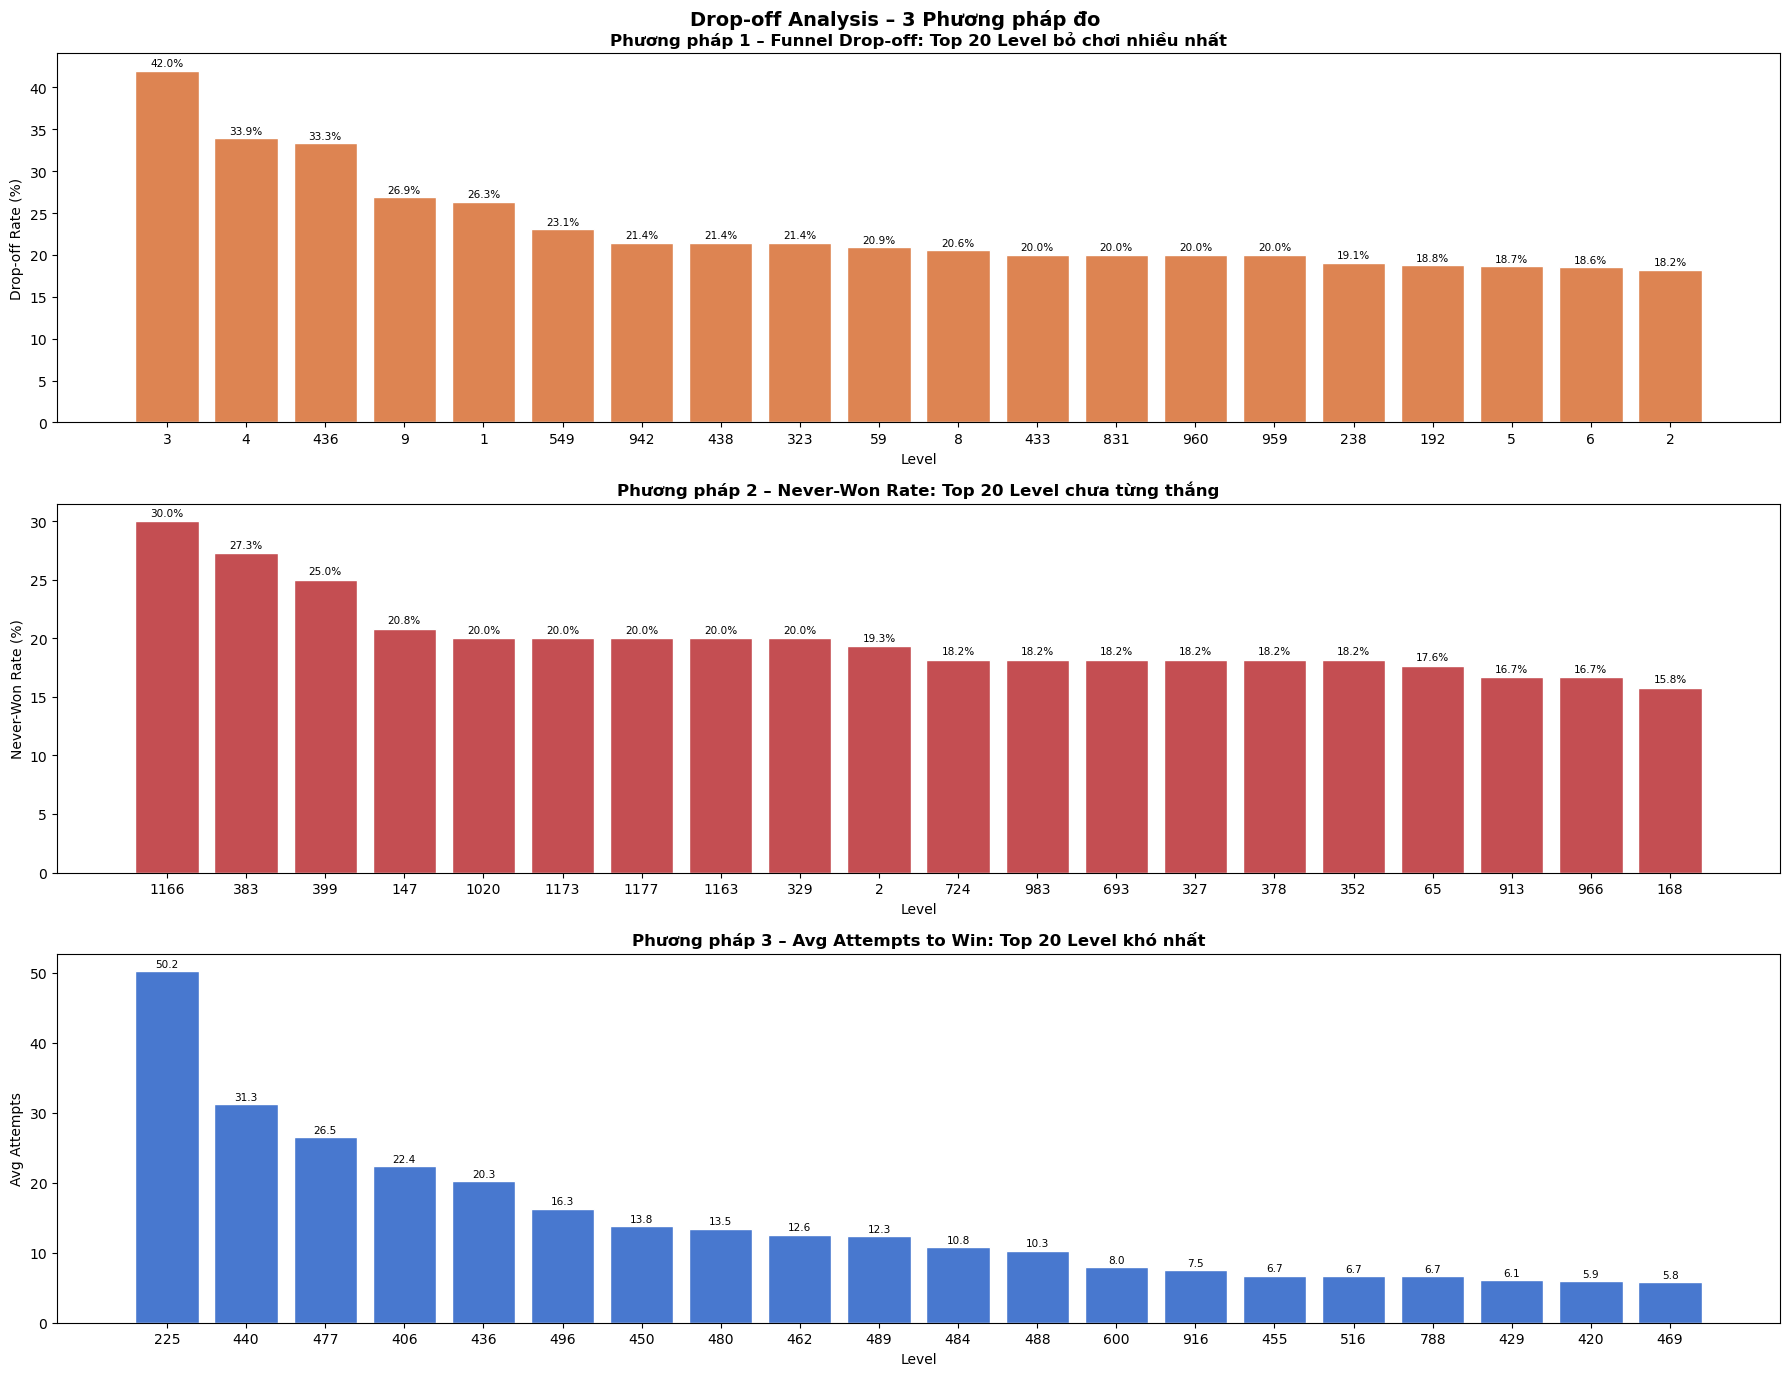

In [22]:
fig, axes = plt.subplots(3, 1, figsize=(18, 14))
fig.suptitle('Drop-off Analysis – 3 Phương pháp đo', fontsize=14, fontweight='bold')

# Method 1: Funnel drop-off
ax = axes[0]
top_funnel = funnel_df.sort_values('dropoff_next_level', ascending=False).head(20)
bars = ax.bar(top_funnel['level'].astype(str), top_funnel['dropoff_next_level']*100,
              color='#DD8452', edgecolor='white')
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f'{bar.get_height():.1f}%',
            ha='center', va='bottom', fontsize=7.5)
ax.set_title('Phương pháp 1 – Funnel Drop-off: Top 20 Level bỏ chơi nhiều nhất', fontweight='bold')
ax.set_ylabel('Drop-off Rate (%)')
ax.set_xlabel('Level')

# Method 2: Never-won rate
ax = axes[1]
top_nw = never_won_df.sort_values('never_won_rate', ascending=False).head(20)
bars = ax.bar(top_nw['level'].astype(int).astype(str), top_nw['never_won_rate']*100,
              color='#C44E52', edgecolor='white')
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f'{bar.get_height():.1f}%',
            ha='center', va='bottom', fontsize=7.5)
ax.set_title('Phương pháp 2 – Never-Won Rate: Top 20 Level chưa từng thắng', fontweight='bold')
ax.set_ylabel('Never-Won Rate (%)')
ax.set_xlabel('Level')

# Method 3: Avg attempts
ax = axes[2]
top_att = avg_attempts_df.sort_values('avg_attempts_to_win', ascending=False).head(20)
bars = ax.bar(top_att['level'].astype(int).astype(str), top_att['avg_attempts_to_win'],
              color='#4878CF', edgecolor='white')
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f'{bar.get_height():.1f}',
            ha='center', va='bottom', fontsize=7.5)
ax.set_title('Phương pháp 3 – Avg Attempts to Win: Top 20 Level khó nhất', fontweight='bold')
ax.set_ylabel('Avg Attempts')
ax.set_xlabel('Level')

plt.tight_layout()
plt.show()

### Điều 3 phương pháp phản ánh từ dữ liệu
Kết quả từ 3 phương pháp cho ra các nhóm level “bất thường” gần như khác nhau hoàn toàn.  
Ví dụ:

- Level 3 đứng đầu về Funnel Drop-off (~42%) nhưng lại không xuất hiện ở nhóm Never-Won Rate hay Avg Attempts cao
- Ngược lại, level 225 cần trung bình hơn 50 lần thử mới thắng nhưng không có tỷ lệ bỏ chơi quá cao

Điều này cho thấy không tồn tại một level “xấu toàn diện”. Mỗi phương pháp đang phản ánh một kiểu vấn đề khác nhau trong trải nghiệm người chơi.

---

### Funnel Drop-off phản ánh điều gì?

Các level có tỷ lệ drop-off cao nhất gồm:

- Level 3 (~42%), Level 4 (~34%), Level 436 (~33%), Level 9 (~26.9%), Level 1 (26.3%)

Tuy nhiên, phần lớn đây đều là các level khá sớm trong hành trình chơi game. Với nhóm level đầu game, tỷ lệ rời bỏ cao chưa chắc xuất phát từ độ khó. Khả năng cao hơn là:

   - Người chơi chưa đủ hứng thú để tiếp tục
   - Gameplay chưa tạo được “hook” đủ mạnh trong phiên chơi đầu tiên
   - Kỳ vọng ban đầu của người chơi không khớp với trải nghiệm thực tế
   
Đặc biệt, các level như 3 hoặc 4 có:

- Avg Attempts rất thấp (~1 lần)
- Never-Won Rate thấp

=> Người chơi vẫn thắng khá dễ, nhưng nhiều người vẫn không quay lại level tiếp theo.

Điều này cho thấy vấn đề nằm nhiều hơn ở:
- onboarding
- pacing đầu game
- khả năng giữ chân người chơi mới thay vì bài toán cân bằng độ khó.

---

### Never-Won Rate phản ánh điều gì?

Các level có Never-Won Rate cao nhất gồm:

- Level 1166 (~30%), Level 383 (~27%), Level 399 (~25%)

Đây là những level mà một bộ phận đáng kể người chơi đã thử nhưng chưa từng vượt qua được.

Khác với Funnel Drop-off, nhóm người chơi này chưa hẳn đã rời game ngay, mà đang bị “kẹt” tại level đó.

Ví dụ:
- Never-Won Rate = 25% nghĩa là cứ 4 người chơi level này thì có khoảng 1 người chưa từng thắng

Đây là tín hiệu khá rõ của:
   - difficulty spike
   - thiết kế level chưa cân bằng hoặc cơ chế chơi chưa đủ trực quan

Tuy nhiên, cần lưu ý rằng nhiều level trong nhóm này chỉ có khoảng 10–15 người chơi, nên kết quả vẫn có thể bị ảnh hưởng bởi sample size nhỏ.

---

### Avg Attempts phản ánh điều gì?

Một số level có số lần thử trung bình cao bất thường:

- Level 225: ~50 lần thử
- Level 440: ~31 lần thử
- Level 477: ~29 lần thử

Đây là nhóm level khiến người chơi phải đầu tư nhiều nỗ lực trước khi chiến thắng. Tuy nhiên, số lần thử cao không hoàn toàn mang ý nghĩa tiêu cực.

Có hai khả năng:

1. Level tạo cảm giác thử thách hợp lý  → người chơi thất bại nhiều lần nhưng vẫn muốn tiếp tục chơi

2. Level gây ức chế hoặc mệt mỏi  → người chơi cố vượt qua nhưng trải nghiệm không còn thú vị

Chỉ riêng Avg Attempts chưa đủ để kết luận level đó “tốt” hay “xấu”.  
Cần kết hợp thêm các chỉ số khác như:
- churn sau level
- session abandonment
- thời lượng chơi
- retention sau khi vượt level để hiểu rõ hơn trải nghiệm thực tế của người chơi.

---

### Insight
Ba phương pháp đang phản ánh ba nhóm vấn đề khác nhau, và mỗi nhóm cần hướng xử lý riêng.

| Nhóm vấn đề | Level điển hình | Ý nghĩa chính | Hướng xử lý đề xuất |
|---|---|---|---|
| Drop-off cao ở level đầu | 1, 3, 4 | Người chơi rời game sớm dù level không khó | Tối ưu onboarding, tutorial, first-session experience |
| Never-Won Rate cao | 383, 399, 1166 | Người chơi bị “kẹt” tại level | Điều chỉnh độ khó, thêm hint hoặc support mechanic |
| Avg Attempts quá cao | 225, 440, 477 | Level yêu cầu quá nhiều lần thử | Kiểm tra xem level đang tạo thử thách hấp dẫn hay gây frustration |

---
## **3️. Phân tích Độ khó của Level**

### 3.1 Định nghĩa chỉ số Độ khó




| Metric                     | Định nghĩa                                    | Ý nghĩa chính                          | Hạn chế                               |
| -------------------------- | --------------------------------------------- | -------------------------------------- | ------------------------------------- |
| Win Rate                   | Tỉ lệ lượt chơi thắng trên tổng số lượt chơi  | Đo xác suất vượt level                 | Bị ảnh hưởng bởi skill distribution   |
| Avg Attempts to Clear      | Số lần thử trung bình trước khi thắng lần đầu | Đo mức độ thử thách thực tế            | Chỉ tính user đã clear level          |
| Avg Attempt Duration       | Thời gian chơi trung bình mỗi lượt            | Phản ánh độ phức tạp của level         | Dễ bị ảnh hưởng bởi idle time         |
| Composite Difficulty Score | Điểm tổng hợp từ nhiều metric difficulty      | So sánh độ khó tổng thể giữa các level | Phụ thuộc cách chuẩn hóa và weighting |


In [24]:
# Difficulty metrics 
level_stats = ends.dropna(subset=['user_id']).groupby('level').agg(
    total_attempts=('is_success','count'),
    wins=('is_success', lambda x: (x == True).sum()),
    avg_time=('time_played','mean'),
    median_time=('time_played','median'),
    unique_users=('user_id','nunique')
).reset_index()

level_stats['level'] = level_stats['level'].astype(int)

level_stats['win_rate']   = (level_stats['wins'] / level_stats['total_attempts']).round(4)
level_stats['loss_rate']  = 1 - level_stats['win_rate']
level_stats['avg_time']   = level_stats['avg_time'].round(2)
level_stats['median_time']= level_stats['median_time'].round(2)
level_stats = level_stats[level_stats['unique_users'] >= 10]

# Merge avg_attempts
level_stats = level_stats.merge(
    avg_attempts_df[['level','avg_attempts_to_win']], on='level', how='left')

# Normalize 0-1 for composite score
def normalize(s):
    return (s - s.min()) / (s.max() - s.min() + 1e-9)

level_stats['norm_loss']     = normalize(level_stats['loss_rate'])
level_stats['norm_attempts'] = normalize(level_stats['avg_attempts_to_win'].fillna(level_stats['avg_attempts_to_win'].median()))
level_stats['norm_time']     = normalize(level_stats['median_time'])
level_stats['difficulty_score'] = (
    (level_stats['norm_loss'] + 
     level_stats['norm_attempts'] +
     level_stats['norm_time'])/3
     ).round(4)

print('Top 10 Hardest Levels (Composite Score):')
cols = ['level','win_rate','avg_attempts_to_win','median_time','difficulty_score']
print(level_stats.sort_values('difficulty_score', ascending=False)[cols].head(10).to_string(index=False))
print()
print('Top 10 Easiest Levels:')
print(level_stats.sort_values('difficulty_score')[cols].head(10).to_string(index=False))

Top 10 Hardest Levels (Composite Score):
 level  win_rate  avg_attempts_to_win  median_time  difficulty_score
   225    0.0210            50.222222        34.39            0.6667
   440    0.0361            31.285714        90.89            0.5683
   477    0.0370            26.545455        87.97            0.5341
   952    0.5000             2.000000       572.42            0.5103
   406    0.0447            22.384615        72.26            0.4935
   966    0.2128             4.000000       318.48            0.4644
   436    0.0554            20.285714        53.01            0.4638
   496    0.0610            16.307692        95.51            0.4612
   788    0.1477             6.692308       224.80            0.4467
   462    0.0777            12.600000       116.75            0.4436

Top 10 Easiest Levels:
 level  win_rate  avg_attempts_to_win  median_time  difficulty_score
    56    0.9783             1.000000        34.46            0.0074
   503    1.0000             1.000000 

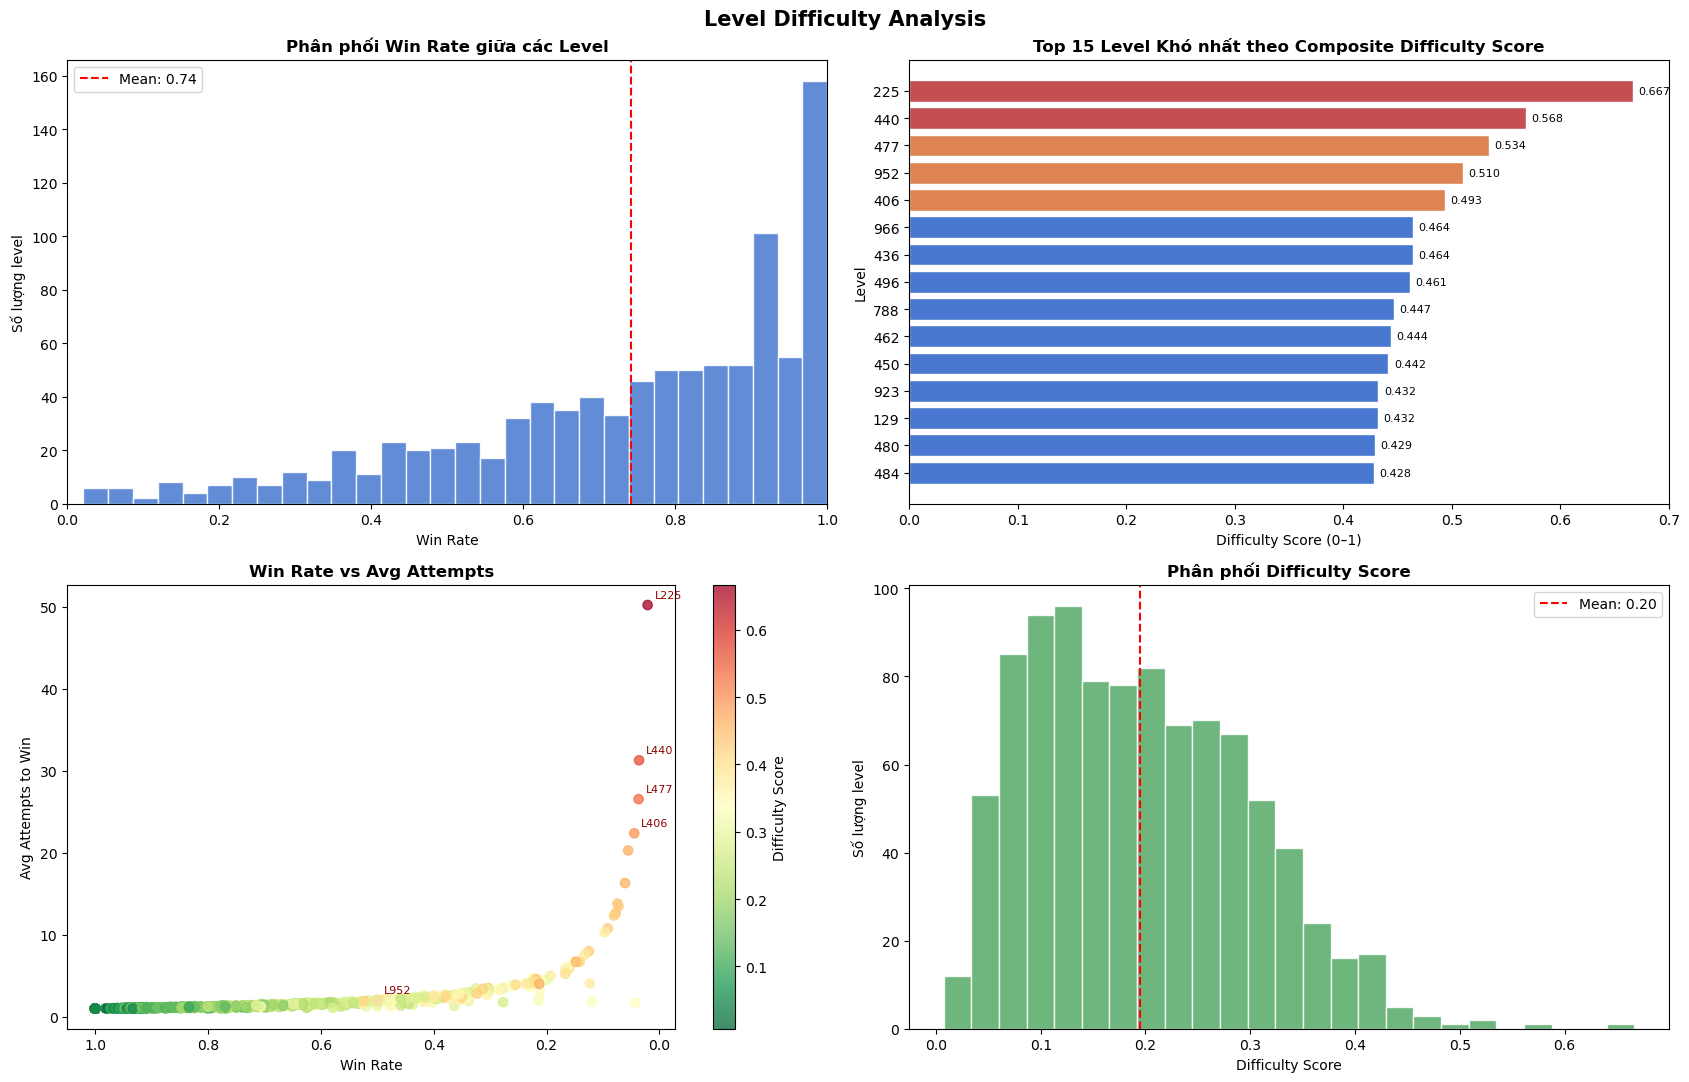

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(17, 11))
fig.suptitle('Level Difficulty Analysis', fontsize=15, fontweight='bold')

# 1) Win rate distribution
ax = axes[0,0]
ax.hist(level_stats['win_rate'], bins=30, color='#4878CF', edgecolor='white', alpha=0.85)
ax.axvline(level_stats['win_rate'].mean(), color='red', linestyle='--',
           label=f'Mean: {level_stats["win_rate"].mean():.2f}')
ax.set_title('Phân phối Win Rate giữa các Level', fontweight='bold')
ax.set_xlabel('Win Rate')
ax.set_ylabel('Số lượng level')
ax.set_xlim(0, 1)
ax.legend()

# 2) Top 15 hardest by composite score
ax = axes[0,1]
top_hard = level_stats.sort_values('difficulty_score', ascending=False).head(15).copy()
# dynamic thresholds
p90 = top_hard['difficulty_score'].quantile(0.90)
p70 = top_hard['difficulty_score'].quantile(0.70)

colors_bar = []

for score in top_hard['difficulty_score']:

    if score >= p90:
        colors_bar.append('#C44E52')   # hardest
    elif score >= p70:
        colors_bar.append('#DD8452')   # medium-hard
    else:
        colors_bar.append('#4878CF')   # relatively lower

bars = ax.barh(top_hard['level'].astype(int).astype(str)[::-1],
               top_hard['difficulty_score'].values[::-1], color=colors_bar[::-1], edgecolor='white')

for bar in bars:
    ax.text(bar.get_width() + 0.005,bar.get_y() + bar.get_height()/2,
        f'{bar.get_width():.3f}',va='center',fontsize=8)

ax.set_title('Top 15 Level Khó nhất theo Composite Difficulty Score', fontweight='bold')
ax.set_xlabel('Difficulty Score (0–1)')
ax.set_ylabel('Level')

# 3) Win rate vs Avg attempts scatter
ax = axes[1,0]
sc = ax.scatter(level_stats['win_rate'], level_stats['avg_attempts_to_win'],
                c=level_stats['difficulty_score'], cmap='RdYlGn_r', alpha=0.75, s=45)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Difficulty Score')

# annotate top difficult outliers
top_outliers = (level_stats.sort_values('difficulty_score', ascending=False).head(5))

# Annotate outliers
for _, row in top_outliers.iterrows():
    ax.annotate(f'L{int(row["level"])}',
                (row['win_rate'], row['avg_attempts_to_win']),
                xytext=(5,5), textcoords='offset points', fontsize=8, color='darkred')
ax.set_title('Win Rate vs Avg Attempts', fontweight='bold')
ax.set_xlabel('Win Rate')
ax.set_ylabel('Avg Attempts to Win')

# hard levels appear on left
ax.invert_xaxis()

# 4) Difficulty Score Distribution
ax = axes[1,1]
ax.hist(
    level_stats['difficulty_score'], bins=25, color='#55A868', edgecolor='white', alpha=0.85
)

mean_diff = level_stats['difficulty_score'].mean()

ax.axvline(mean_diff, color='red', linestyle='--', label=f'Mean: {mean_diff:.2f}')

ax.set_title('Phân phối Difficulty Score', fontweight='bold')
ax.set_xlabel('Difficulty Score')
ax.set_ylabel('Số lượng level')
ax.legend()

plt.tight_layout()
plt.show()



**Level 225 – Outlier cực đoan:**
- Win rate: 2.1% | Avg attempts: 50.3 lần/user | Difficulty score: 0.79
- 905 lượt chơi, nhưng gần như không ai thắng → Có thể bị lỗi balance hoặc cố tình là "boss level"

**Level 440, 477, 506 – Nhóm khó:**
- Win rate ~3-4%, avg attempts 20-32 lần
- Nằm trong khoảng level 400-500 → Cụm level này có thể quá khó đột ngột

**Level 129 – Anomaly thời gian:**
- Avg time: 1,559s (~26 phút/lượt!) nhưng win rate = 22% → Không phải khó về skill mà có thể là level marathon/puzzle dài

### 3.2 Phân tích level bất thường nổi bật

**Level 225 – Outlier difficulty rõ rệt**

- Win rate 2.1%, avg attempts 50.3 lần, difficulty score cao nhất toàn dataset — tín hiệu nhất quán ở cả 3 chiều, trên tổng số 905 attempts — đủ lớn để giảm khả năng đây chỉ là nhiễu dữ liệu ngẫu nhiên.

Câu hỏi cần trả lời: đây là boss level được thiết kế cố ý, hay difficulty spike vượt quá kỳ vọng người chơi? Dù là trường hợp nào, level 225 vẫn là candidate mạnh nhất để ưu tiên kiểm tra lại balance, hint system và progression pacing.


**Nhóm level 400–500 – Difficulty cluster**

- Ba level khó nhất sau level 225 đều nằm trong cùng một khoảng: level 440 (win rate 3.6%, avg attempts 31+), 477 (3.7%, 26+) và 406 (4.5%, 22+). Việc nhiều level khó tập trung trong một range hẹp có thể phản ánh difficulty curve tăng mạnh ở mid-game, hoặc đây là phase gameplay với cơ chế phức tạp hơn bình thường.

Cần cross-check với progression timeline để xác nhận đây là difficulty spike thực sự hay chỉ là vùng endgame được thiết kế có chủ ý.


**Level 129 – Time-play anomaly**

- Level 129 có thời gian chơi trung bình ~26 phút/lượt — bất thường so với phần còn lại — trong khi win rate (~22%) và difficulty score chỉ ở mức trung bình. Level này không nổi bật về độ khó, nhưng lại bất thường về thời lượng chơi: có thể là level thiên về puzzle/exploration, hoặc chứa cơ chế khiến session bị kéo dài ngoài ý muốn.

- Tuy nhiên metric time_played có dấu hiệu outlier trong dataset. Nên kiểm tra thêm median time, tỉ lệ AFK/background session và distribution của time_played tại level này trước khi kết luận.

---
## **4️. Export dữ liệu cho Power BI**

In [34]:
# Full metrics table 
final = level_stats.merge(funnel_df[['level','dropoff_next_level']], on='level', how='left')
final = final.merge(never_won_df[['level','never_won_users','never_won_rate']], on='level', how='left')
final['level'] = final['level'].astype(int)

# fill missing values
final['dropoff_next_level'] = (
    final['dropoff_next_level'].fillna(0)
)

# Difficulty segmentation (quantile-based) 
q90 = final['difficulty_score'].quantile(0.90)
q75 = final['difficulty_score'].quantile(0.75)
median_diff = final['difficulty_score'].median()

def segment(score):
    if score >= q90:
        return '🔴 Very Hard'
    elif score >= q75:
        return '🟠 Hard'
    elif score >= median_diff:
        return '🟡 Medium'
    else:
        return '🟢 Easy'

final['difficulty_label'] = final['difficulty_score'].apply(segment)

# useful BI flag
final['is_outlier_level'] = (final['difficulty_score'] >= q90)

# remove helper columns
final = final.drop(
    columns=['norm_loss', 'norm_attempts', 'norm_time', 'diff_quartile'],errors='ignore'
)

# round metrics for cleaner BI display
metric_cols = [
    'difficulty_score',
    'win_rate',
    'loss_rate',
    'avg_attempts_to_win',
    'avg_time',
    'median_time',
    'dropoff_next_level',
    'never_won_rate'
]

final[metric_cols] = (
    final[metric_cols]
    .round(4)
)

# reorder columns 
final = final[
    [
        'level',
        'difficulty_label',
        'difficulty_score',

        'win_rate',
        'loss_rate',

        'avg_attempts_to_win',

        'avg_time',
        'median_time',

        'dropoff_next_level',

        'never_won_users',
        'never_won_rate',

        'total_attempts',
        'wins',
        'unique_users'
    ]
]

# sort hardest first
final = final.sort_values('difficulty_score', ascending=False)

# export aggregated metrics
final.to_csv('level_full_metrics.csv',index=False)

print(f'Exported: level_full_metrics.csv ({len(final)} levels)')

print('\nDifficulty distribution:')
print(final['difficulty_label'].value_counts())


print('\nTop 5 hardest levels:')
print(
    final[
        [
            'level',
            'difficulty_score',
            'difficulty_label'
        ]
    ]
    .head(5)
    .to_string(index=False)
)

# Export raw level_end 

ends_export = ends[
    ends['event_name'] == 'level_end'
].copy()

# keep only useful columns
ends_export = ends_export[
    [
        'user_id',
        'event_timestamp',

        'level',
        'is_success',
        'time_played',

        'country',
        'game_mode',

        'device_category',
        'mobile_brand_name',
        'operating_system',

        'app_version',
        'session_id'
    ]
]

# clean types
ends_export['level'] = (
    ends_export['level']
    .astype('Int64')
)

# sort by timestamp
ends_export = ends_export.sort_values(
    'event_timestamp'
)

# export raw drilldown table
ends_export.to_csv(
    'level_end_raw.csv',
    index=False
)

print(
    f'\nExported: level_end_raw.csv ({len(ends_export)} records)'
)


Exported: level_full_metrics.csv (948 levels)

Difficulty distribution:
difficulty_label
🟢 Easy         474
🟡 Medium       237
🟠 Hard         142
🔴 Very Hard     95
Name: count, dtype: int64

Top 5 hardest levels:
 level  difficulty_score difficulty_label
   225            0.6667      🔴 Very Hard
   440            0.5683      🔴 Very Hard
   477            0.5341      🔴 Very Hard
   952            0.5103      🔴 Very Hard
   406            0.4935      🔴 Very Hard

Exported: level_end_raw.csv (52717 records)


---
## **5️. Dashboard Summary Chart (Tổng hợp)**

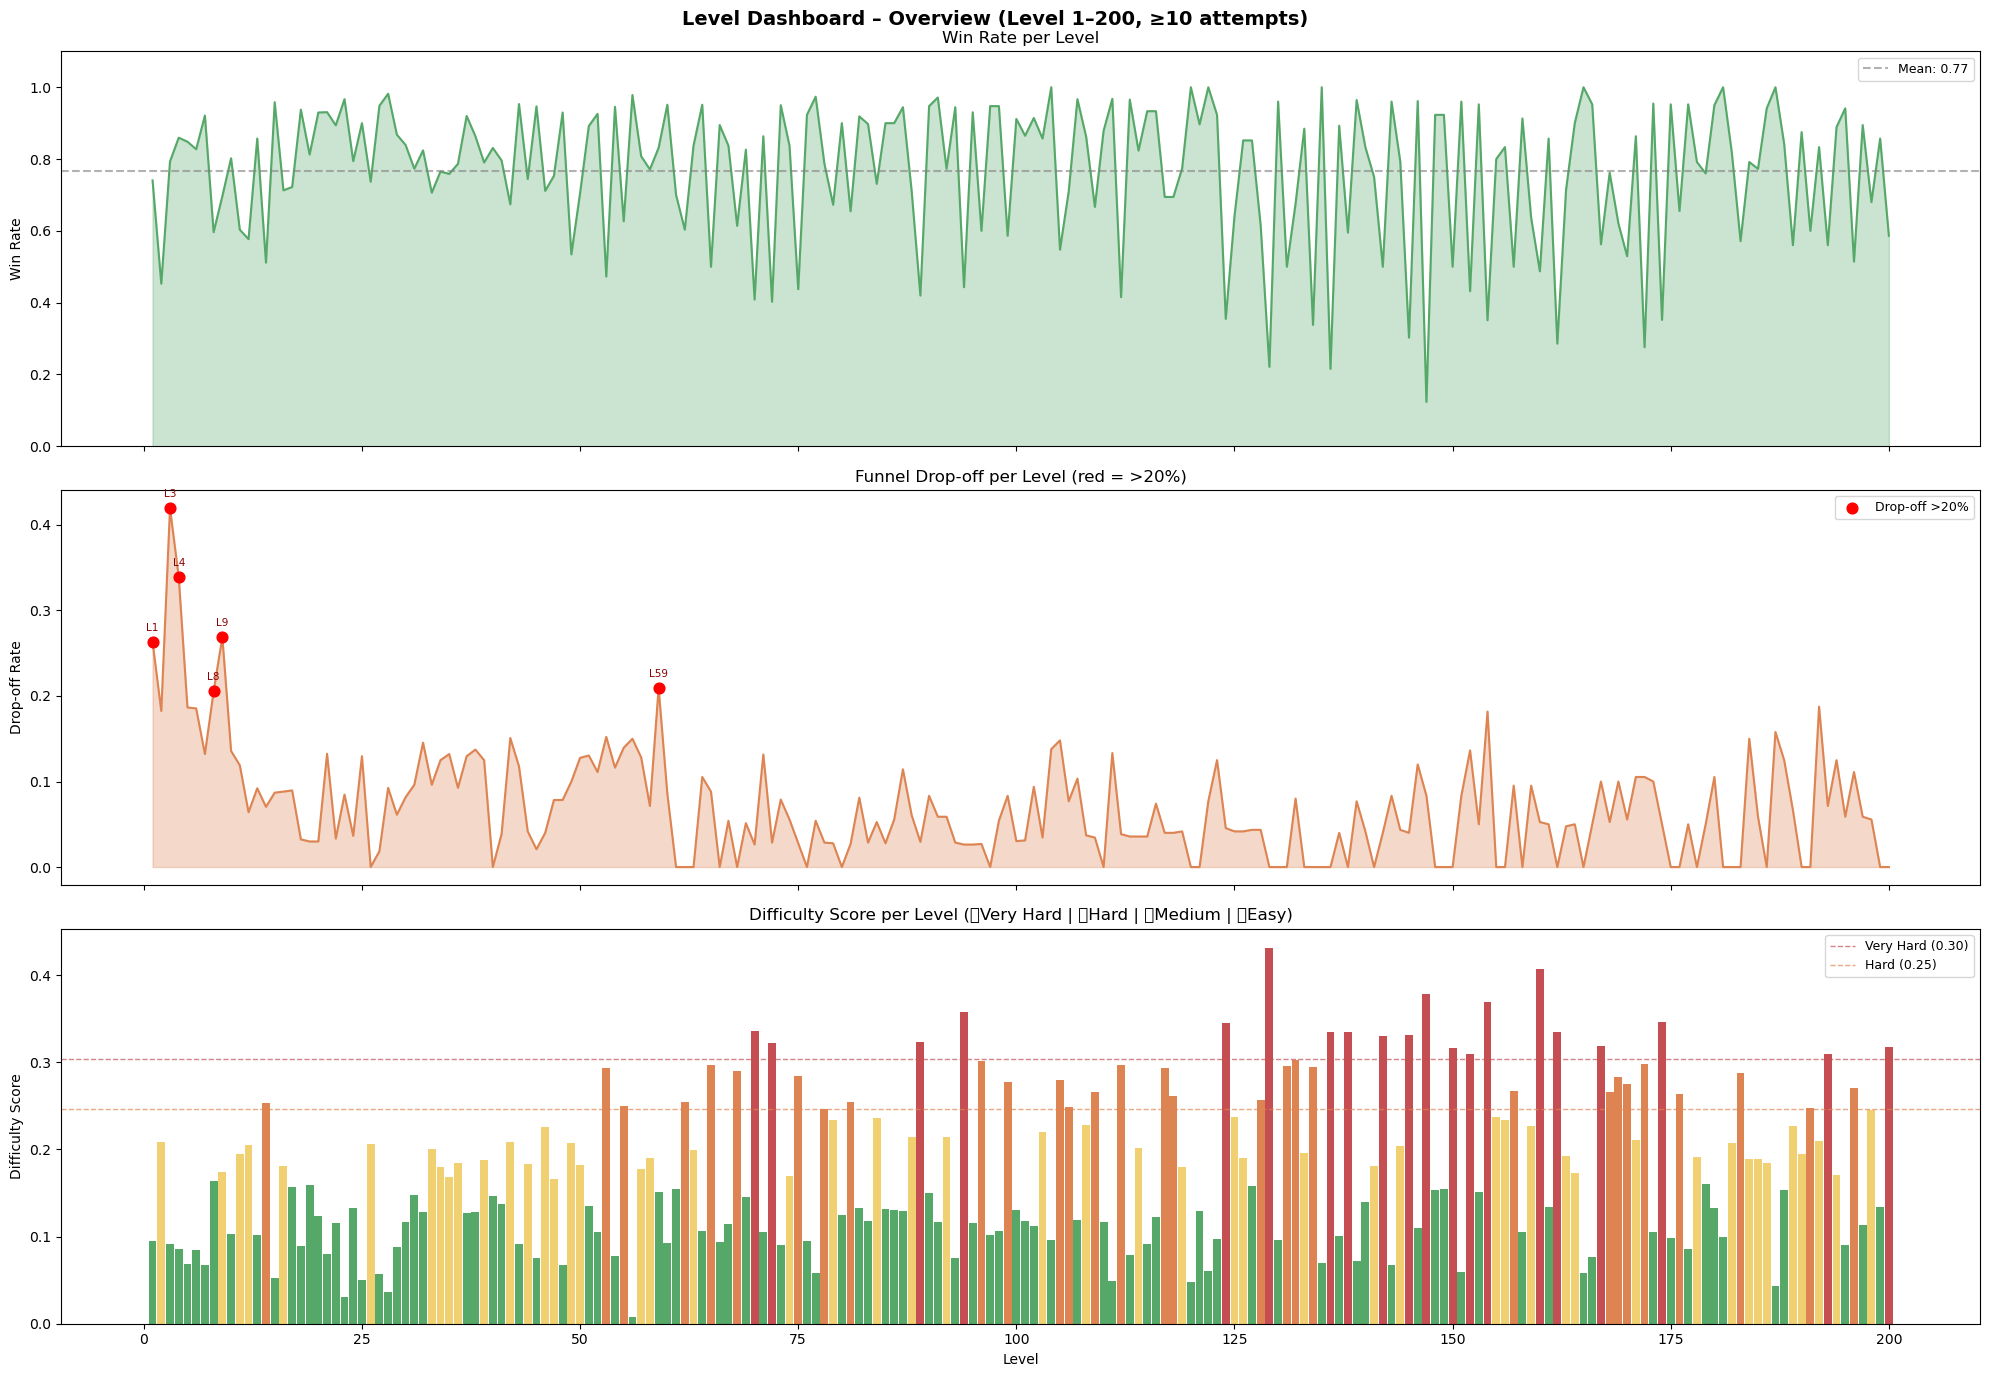

In [35]:
# Focus on levels 1-200 (most popular, enough data)
focus = final[(final['level'] <= 200) & (final['total_attempts'] >= 10)].copy().sort_values('level')

fig, axes = plt.subplots(3, 1, figsize=(20, 14), sharex=True)
fig.suptitle('Level Dashboard – Overview (Level 1–200, ≥10 attempts)', fontsize=14, fontweight='bold')

# Row 1: Win Rate
ax = axes[0]
ax.fill_between(focus['level'], focus['win_rate'], alpha=0.3, color='#55A868')
ax.plot(focus['level'], focus['win_rate'], color='#55A868', linewidth=1.5)
ax.axhline(focus['win_rate'].mean(), color='gray', linestyle='--', alpha=0.6,
           label=f'Mean: {focus["win_rate"].mean():.2f}')
ax.set_ylabel('Win Rate')
ax.set_title('Win Rate per Level')
ax.set_ylim(0, 1.1)
ax.legend(fontsize=9)

# Row 2: Drop-off funnel
ax = axes[1]
focus2 = focus.dropna(subset=['dropoff_next_level'])
ax.fill_between(focus2['level'], focus2['dropoff_next_level'], alpha=0.3, color='#DD8452')
ax.plot(focus2['level'], focus2['dropoff_next_level'], color='#DD8452', linewidth=1.5)
# Highlight spike > 0.2
spikes = focus2[focus2['dropoff_next_level'] > 0.2]
ax.scatter(spikes['level'], spikes['dropoff_next_level'], color='red', s=60, zorder=5, label='Drop-off >20%')
for _, row in spikes.iterrows():
    ax.annotate(f'L{int(row["level"])}', (row['level'], row['dropoff_next_level']),
                xytext=(0, 8), textcoords='offset points', fontsize=7.5, ha='center', color='darkred')
ax.set_ylabel('Drop-off Rate')
ax.set_title('Funnel Drop-off per Level (red = >20%)')
ax.legend(fontsize=9)

# Row 3: Difficulty score with color bands
ax = axes[2]
q90 = focus['difficulty_score'].quantile(0.90)
q75 = focus['difficulty_score'].quantile(0.75)
median_diff = focus['difficulty_score'].median()

cmap_colors = focus['difficulty_score'].apply(
    lambda x:
        '#C44E52' if x >= q90 else
        '#DD8452' if x >= q75 else
        '#F0D070' if x >= median_diff else
        '#55A868'
)

ax.bar(focus['level'], focus['difficulty_score'], color=cmap_colors, width=0.9)
ax.axhline(q90, color='#C44E52', linestyle='--', alpha=0.7, linewidth=1, label=f'Very Hard ({q90:.2f})')
ax.axhline(q75, color='#DD8452', linestyle='--', alpha=0.7, linewidth=1, label=f'Hard ({q75:.2f})')
ax.set_ylabel('Difficulty Score')
ax.set_xlabel('Level')
ax.set_title('Difficulty Score per Level (🔴Very Hard | 🟠Hard | 🟡Medium | 🟢Easy)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

---
## 📊 Kết luận & Khuyến nghị

### Findings chính

| Level | Tín hiệu nổi bật | Chỉ số | Ưu tiên |
|-------|--------|--------|---------|
| **225** | Difficulty outlier rõ rệt |Win rate 2.1%, avg attempts 50+ | High |
| **3, 4** | Early-game drop-off cao | Funnel drop-off 42%, 34% | High |
| **440, 477** | Cụm level 400-500 quá khó | Win rate ~3–4%, attempts cao | High |
| **129** | Thời gian chơi bất thường | Median/avg session time rất cao  | Investigate |
| **1, 9** | Người chơi rời game sớm ở giai đoạn onboarding | Drop-off >25% | Medium |

### Khuyến nghị
1. **Level 225:** có difficulty vượt xa phần còn lại của progression curve. Cần kiểm tra thêm liệu đây là boss level được thiết kế có chủ ý, hay difficulty spike vượt quá kỳ vọng người chơi.
2. **Level 3-4:** Early game drop-off cao ảnh hưởng retention – cần review onboarding
3. **Tablet users có win rate cao hơn đáng kể** so với mobile users. Tuy nhiên cần kiểm tra thêm sample size và user distribution trước khi kết luận đây là khác biệt do UI/UX.
4. **17.5% level_start không có level_end** → user exit mid-game, cần phân tích thêm exit timing

